#Linear Regression

is an approach that tries to find a linear relationship between a dependent variable and an independent variable by minimizing the distance as shown below.

In this colab, we will learn how to implement a simple linear regression model using PyTorch.

Let’s consider a very basic linear equation i.e., y=2x+1. Here, ‘x’ is the independent variable and y is the dependent variable. We’ll use this equation to create a dummy dataset which will be used to train this linear regression model. Following is the code for creating the dataset.

In [15]:
import numpy as np

# Create dummy data for training
x_values = [i for i in range(11)]
x_train = np.array(x_values, dtype=np.float32)
x_train = x_train.reshape(-1, 1)

y_values = [2*i + 1 for i in x_values]
y_train = np.array(y_values, dtype=np.float32)
y_train = y_train.reshape(-1, 1)

Once we have created the dataset, we can start writing the code for our model. First thing will be to define the model architecture. We do that using the following piece of code.

In [16]:
import torch
from torch.autograd import Variable

class linearRegression(torch.nn.Module):
    def __init__(self, inputSize, outputSize):
        super(linearRegression, self).__init__()
        self.linear = torch.nn.Linear(inputSize, outputSize)

    def forward(self, x):
        out = self.linear(x)
        return out

We defined a class for linear regression, that inherits torch.nn.Module which is the basic Neural Network module containing all the required functions. Our Linear Regression model only contains one simple linear function.

Next, we instantiate the model using the following code.

In [17]:
in_feature_size = 1       # Takes variable 'x' - 1 features
out_feature_size= 1       # Takes variable 'y'
learningRate = 0.01
epochs = 100

model = linearRegression(in_feature_size, out_feature_size)

if torch.cuda.is_available():
    model.cuda()

After that, we initialize the loss (Mean Squared Error) and optimization (Adam) functions that we’ll use in the training of this model.

In [18]:
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learningRate)

After completing all the initializations, we can now begin to train our model. Following is the code for training the model.

In [19]:
training_loss = []

for epoch in range(epochs):
    # Converting inputs and labels to Variable
    if torch.cuda.is_available():
        inputs = Variable(torch.from_numpy(x_train).cuda())
        labels = Variable(torch.from_numpy(y_train).cuda())
    else:
        inputs = Variable(torch.from_numpy(x_train))
        labels = Variable(torch.from_numpy(y_train))

    # Clear gradient buffers because we don't want any gradient from previous epoch to carry forward, dont want to cummulate gradients
    optimizer.zero_grad()

    # Get output from the model, given the inputs
    outputs = model(inputs)

    # Get loss for the predicted output
    loss = criterion(outputs, labels)
    # Get gradients w.r.t to parameters
    loss.backward()

    # Update parameters
    optimizer.step()

    print('epoch {}, loss {}'.format(epoch, loss.item()))

    training_loss.append(loss.item())

epoch 0, loss 270.2977600097656
epoch 1, loss 268.0728454589844
epoch 2, loss 265.8573913574219
epoch 3, loss 263.6515197753906
epoch 4, loss 261.45538330078125
epoch 5, loss 259.2691955566406
epoch 6, loss 257.093017578125
epoch 7, loss 254.9270782470703
epoch 8, loss 252.771484375
epoch 9, loss 250.6263885498047
epoch 10, loss 248.49192810058594
epoch 11, loss 246.3682098388672
epoch 12, loss 244.25534057617188
epoch 13, loss 242.15350341796875
epoch 14, loss 240.062744140625
epoch 15, loss 237.9832305908203
epoch 16, loss 235.91500854492188
epoch 17, loss 233.8582000732422
epoch 18, loss 231.81292724609375
epoch 19, loss 229.7792205810547
epoch 20, loss 227.7572021484375
epoch 21, loss 225.7469024658203
epoch 22, loss 223.74842834472656
epoch 23, loss 221.76181030273438
epoch 24, loss 219.7871551513672
epoch 25, loss 217.824462890625
epoch 26, loss 215.8738250732422
epoch 27, loss 213.93524169921875
epoch 28, loss 212.00877380371094
epoch 29, loss 210.09442138671875
epoch 30, loss 2

Text(0, 0.5, 'Training loss')

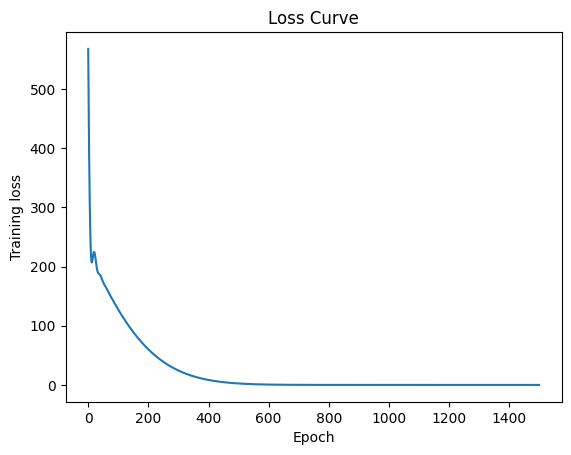

In [28]:
import matplotlib.pyplot as plt

plt.plot(np.arange(epochs), training_loss)
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Training loss')

Now that our Linear Regression Model is trained, let’s test it. Since it’s a very trivial model, we’ll test this on our existing dataset and also plot to see the original vs the predicted outputs.

[[0.21021068]
 [0.6007186 ]
 [0.9912265 ]
 [1.3817344 ]
 [1.7722423 ]
 [2.1627502 ]
 [2.5532582 ]
 [2.943766  ]
 [3.3342738 ]
 [3.7247818 ]
 [4.1152897 ]]


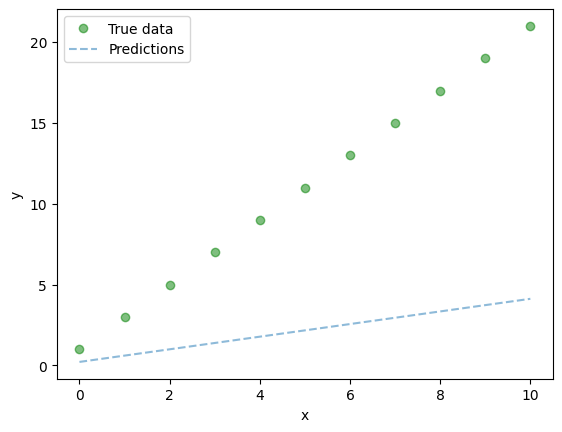

In [21]:
with torch.no_grad(): # We don't need gradients in the testing phase
    if torch.cuda.is_available():
        predicted = model(Variable(torch.from_numpy(x_train).cuda())).cpu().data.numpy()
    else:
        predicted = model(Variable(torch.from_numpy(x_train))).data.numpy()
    print(predicted)

plt.clf()
plt.plot(x_train, y_train, 'go', label='True data', alpha=0.5)
plt.plot(x_train, predicted, '--', label='Predictions', alpha=0.5)
plt.legend(loc='best')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [22]:
# To infer y when x = 7
x_infer = np.array([7], dtype=np.float32)
x_infer = x_infer.reshape(-1, 1)

with torch.no_grad(): # We don't need gradients in the testing phase
    if torch.cuda.is_available():
        predicted = model(Variable(torch.from_numpy(x_infer).cuda())).cpu().data.numpy()
    else:
        predicted = model(Variable(torch.from_numpy(x_infer))).data.numpy()
    print('when x = 7, y = ', predicted)

when x = 7, y =  [[2.943766]]


In [23]:
# Print the weight
for param in model.parameters():
  print(param.data)

tensor([[0.3905]], device='cuda:0')
tensor([0.2102], device='cuda:0')


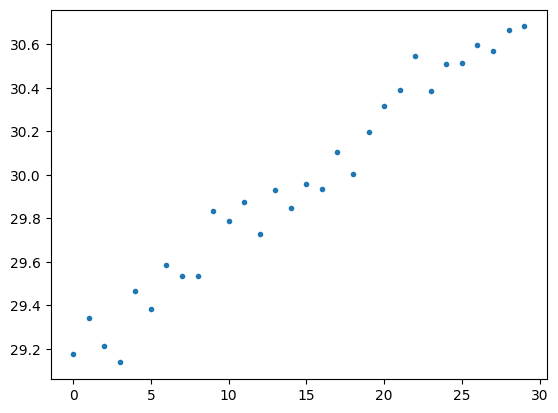

In [24]:
x_values = [i for i in range(30)]
x = np.array(x_values, dtype=np.float32)
x = x.reshape(-1, 1)

y_values = [0.052*i + 29.21  for i in x_values] + np.random.normal(0,0.1,30)
y = np.array(y_values, dtype=np.float32)
y = y.reshape(-1, 1)

plt.plot(x, y, '.')

In [25]:
import torch
from torch.autograd import Variable
class linearRegression(torch.nn.Module):
    def __init__(self, inputSize, outputSize):
        super(linearRegression, self).__init__()
        self.linear = torch.nn.Linear(inputSize, outputSize)

    def forward(self, x):
        out = self.linear(x)
        return out

inputDim = 1        # Takes variable 'x' - 10 features
outputDim = 1       # Takes variable 'y'
learningRate = 0.1
epochs = 1500

model = linearRegression(inputDim, outputDim)

if torch.cuda.is_available():
    model.cuda()

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learningRate)

training_loss = []

for epoch in range(epochs):
    # Converting inputs and labels to Variable
    if torch.cuda.is_available():
        inputs = Variable(torch.from_numpy(x).cuda())
        labels = Variable(torch.from_numpy(y).cuda())
    else:
        inputs = Variable(torch.from_numpy(x))
        labels = Variable(torch.from_numpy(y))

    # Clear gradient buffers because we don't want any gradient from previous epoch to carry forward, dont want to cummulate gradients
    optimizer.zero_grad()

    # Get output from the model, given the inputs
    outputs = model(inputs)

    # Get loss for the predicted output
    loss = criterion(outputs, labels)
    # Get gradients w.r.t to parameters
    loss.backward()

    # Update parameters
    optimizer.step()

    print('epoch {}, loss {}'.format(epoch, loss.item()))

    training_loss.append(loss.item())

epoch 0, loss 567.8073120117188
epoch 1, loss 503.5787353515625
epoch 2, loss 445.8594665527344
epoch 3, loss 394.7301940917969
epoch 4, loss 350.2168884277344
epoch 5, loss 312.27740478515625
epoch 6, loss 280.7872314453125
epoch 7, loss 255.5242919921875
epoch 8, loss 236.15576171875
epoch 9, loss 222.2279052734375
epoch 10, loss 213.16355895996094
epoch 11, loss 208.26980590820312
epoch 12, loss 206.75904846191406
epoch 13, loss 207.78465270996094
epoch 14, loss 210.48846435546875
epoch 15, loss 214.05484008789062
epoch 16, loss 217.7625732421875
epoch 17, loss 221.02670288085938
epoch 18, loss 223.4235076904297
epoch 19, loss 224.69708251953125
epoch 20, loss 224.74887084960938
epoch 21, loss 223.61463928222656
epoch 22, loss 221.43411254882812
epoch 23, loss 218.41807556152344
epoch 24, loss 214.81687927246094
epoch 25, loss 210.89222717285156
epoch 26, loss 206.8936309814453
epoch 27, loss 203.04014587402344
epoch 28, loss 199.50758361816406
epoch 29, loss 196.42066955566406
epoc

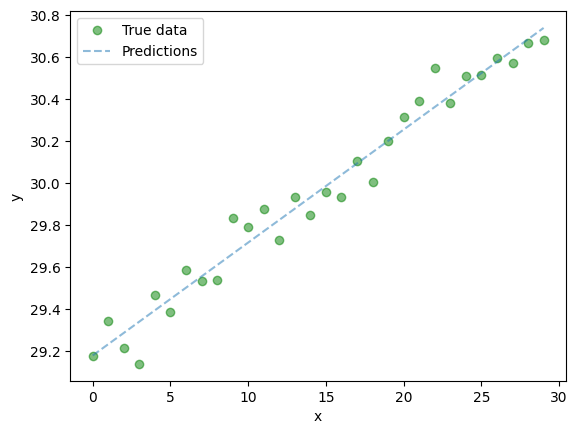

In [26]:
with torch.no_grad(): # We don't need gradients in the testing phase
    if torch.cuda.is_available():
        predicted = model(Variable(torch.from_numpy(x).cuda())).cpu().data.numpy()
    else:
        predicted = model(Variable(torch.from_numpy(x))).data.numpy()

plt.clf()
plt.plot(x, y, 'go', label='True data', alpha=0.5)
plt.plot(x, predicted, '--', label='Predictions', alpha=0.5)
plt.legend(loc='best')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [27]:
# Print the weight
for param in model.parameters():
  print(param.data)

tensor([[0.0538]], device='cuda:0')
tensor([29.1771], device='cuda:0')
